# **Install Library**

In [1]:
# import subprocess
# from importlib.metadata import distributions

# keep = {
#     "pip", "setuptools", "wheel", "wrapt",
#     "numpy", "pandas", "scipy", "matplotlib", "seaborn",
#     "torch", "torchvision", "torchaudio",
#     "transformers", "datasets", "accelerate",
#     "peft", "trl", "sentencepiece", "evaluate",
#     "tqdm", "ipywidgets", "jupyterlab-widgets",
#     "scikit-learn", "joblib", "protobuf", "pydantic"
# }

# installed_packages = [dist.metadata["Name"].lower() for dist in distributions()]
# to_uninstall = [pkg for pkg in installed_packages if pkg not in keep]

# if to_uninstall:
#     subprocess.run(["pip", "uninstall", "--quiet", "--yes"] + to_uninstall)

In [2]:
!pip install --quiet --upgrade transformers peft accelerate trl sentencepiece evaluate datasets protobuf==4.25.3 pydantic==2.8.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.2/125.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.9/423.9 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.4/556.4 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# **Import & Setup**

In [3]:
import os
import time
import shutil
import zipfile
import torch
from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, TrainerCallback, DataCollatorForSeq2Seq, logging
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer
import evaluate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.simplefilter(action='ignore', category=FutureWarning)

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Not found GPU")

2025-11-13 13:20:56.016440: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763040056.226310      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763040056.274266      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPU: Tesla T4


# **Load Dataset**

In [4]:
dataset = load_dataset("ncduy/mt-en-vi")

train_dataset = dataset["train"].shuffle(seed=42).select(range(25_000))
valid_dataset = dataset["validation"].shuffle(seed=42).select(range(2_000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(2_000))

print(f"Train: {len(train_dataset)}, Validation: {len(valid_dataset)}, Test: {len(test_dataset)}")

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/597M [00:00<?, ?B/s]

valid.csv:   0%|          | 0.00/2.45M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/2.43M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2884451 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11316 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11225 [00:00<?, ? examples/s]

Train: 25000, Validation: 2000, Test: 2000


# **EDA**

=== First 5 rows ===


,en,vi,source
0,"""education and leading me to providing service...","""nơi giáo dục và dìu dắt tôi để tôi có thể phụ...",OpenSubtitles v2018
1,"Because of the big, bad Fizzle Bomber?",Có phải vì Kẻ Ném Bom Xì Xèo xấu xa?,OpenSubtitles v2018
2,"The author of numerous collections of poems, s...","Là tác giả của nhiều bộ sưu tập thơ, truyện ng...",wikimedia v20210402
3,"R's are less than one, no spread of the disease;","R nhỏ hơn một, không có sự lây truyền bệnh.",QED v2.0a
4,"Well, I'm oversexed... I mean...","À, tôi khát tình... ý tôi là...",OpenSubtitles v2018


en        0
vi        0
source    0
dtype: int64
Duplicate EN–VI pairs: 0
Duplicate English only: 0
Duplicate Vietnamese only: 0

Missing values:
en        0
vi        0
source    0
dtype: int64
Empty English strings: 0
Empty Vietnamese strings: 0

Unique English sentences: 25000
Unique Vietnamese sentences: 25000

=== Text Length Statistics ===

English:
min       1.00
10%       5.00
25%       7.00
50%      11.00
75%      18.00
90%      27.00
max     181.00
mean     13.87
Name: en_len, dtype: float64

Vietnamese:
min       2.00
10%       6.00
25%       8.00
50%      13.00
75%      24.00
90%      36.00
max     202.00
mean     18.01
Name: vi_len, dtype: float64


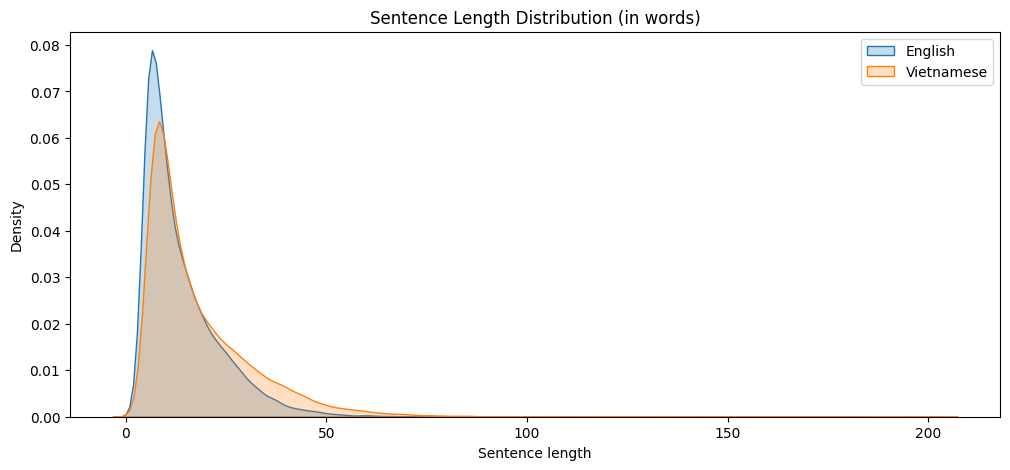

In [5]:
df = pd.DataFrame(train_dataset)

print("=== First 5 rows ===")
display(df.head())

print(df.isnull().sum())

# Check duplicates
dup_both = df.duplicated(subset=["en", "vi"]).sum()
dup_en = df.duplicated(subset=["en"]).sum()
dup_vi = df.duplicated(subset=["vi"]).sum()

print(f"Duplicate EN–VI pairs: {dup_both}")
print(f"Duplicate English only: {dup_en}")
print(f"Duplicate Vietnamese only: {dup_vi}")

# Check null or empty values
null_counts = df.isnull().sum()
empty_en = (df["en"].str.strip() == "").sum()
empty_vi = (df["vi"].str.strip() == "").sum()

print(f"\nMissing values:\n{null_counts}")
print(f"Empty English strings: {empty_en}")
print(f"Empty Vietnamese strings: {empty_vi}")

# Count unique values
print(f"\nUnique English sentences: {df['en'].nunique()}")
print(f"Unique Vietnamese sentences: {df['vi'].nunique()}")

print("\n=== Text Length Statistics ===")

df["en_len"] = df["en"].apply(lambda x: len(x.split()))
df["vi_len"] = df["vi"].apply(lambda x: len(x.split()))

def describe_custom(col):
    desc = col.describe(percentiles=[.1, .25, .5, .75, .9])
    return desc[["min", "10%", "25%", "50%", "75%", "90%", "max", "mean"]].round(2)

print("\nEnglish:")
print(describe_custom(df["en_len"]))

print("\nVietnamese:")
print(describe_custom(df["vi_len"]))

plt.figure(figsize=(12,5))
sns.kdeplot(df["en_len"], label="English", fill=True)
sns.kdeplot(df["vi_len"], label="Vietnamese", fill=True)
plt.title("Sentence Length Distribution (in words)")
plt.xlabel("Sentence length")
plt.ylabel("Density")
plt.legend()
plt.show()

# **Tokenize & Prompt Format**

In [6]:
def format_example(example):
    prompt = f"Translate English to Vietnamese:\nEnglish: {example['en']}\nVietnamese:"
    target = example['vi']
    return {"text": prompt + " " + target}

train_dataset = train_dataset.map(format_example)
valid_dataset = valid_dataset.map(format_example)

# Tokenize
model_name = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=256,
        padding="max_length"
    )

tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=train_dataset.column_names)
tokenized_valid = valid_dataset.map(tokenize_function, batched=True, remove_columns=valid_dataset.column_names)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

# **Load Model**

In [7]:
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.config.bos_token_id = tokenizer.bos_token_id

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

# **LoRA Configuration**

In [8]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # Qwen2.5
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 1,081,344 || all params: 495,114,112 || trainable%: 0.2184


# **Training Arguments**

In [9]:
training_args = TrainingArguments(
    output_dir="./qwen2.5-lora-en-vi",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=True,
    logging_steps=5,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=500,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    greater_is_better=False,
    report_to="none",
    warmup_steps=100,
    lr_scheduler_type="cosine",
    dataloader_num_workers=2,
    remove_unused_columns=False,
    save_strategy="steps",
    gradient_checkpointing=False,
)

# **TrainerCallback**

In [10]:
class TimeLoggingCallback(TrainerCallback):
    def __init__(self, interval_minutes=5):
        self.interval = interval_minutes * 60
        self.last_log_time = time.time()
    
    def on_step_end(self, args, state, control, **kwargs):
        now = time.time()
        if now - self.last_log_time >= self.interval:
            print(f"-> Step {state.global_step} / {state.max_steps} — "
                  f"Epoch {state.epoch if state.epoch is not None else 0:.2f} — ")
            self.last_log_time = now
        return control

# **Trainer & Training**

In [11]:
time_callback = TimeLoggingCallback(interval_minutes=5)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    callbacks=[time_callback]
)

trainer.train()

Truncating train dataset:   0%|          | 0/25000 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,0.541900,0.522579,0.570346,819200.000000,0.905904
200,0.464700,0.471455,0.524600,1638400.000000,0.909843
300,0.494300,0.461261,0.506452,2457600.000000,0.911384
400,0.441200,0.457364,0.507439,3276800.000000,0.912078
500,0.454200,0.454701,0.509984,4096000.000000,0.912553
600,0.454900,0.453214,0.500307,4915200.000000,0.912869
700,0.450200,0.451495,0.499175,5734400.000000,0.913071
800,0.479400,0.459418,0.565274,6547456.000000,0.913443
900,0.426200,0.452924,0.531455,7366656.000000,0.913410
1000,0.454000,0.450210,0.519867,8185856.000000,0.913590


-> Step 115 / 2346 — Epoch 0.15 — 
-> Step 231 / 2346 — Epoch 0.30 — 
-> Step 347 / 2346 — Epoch 0.44 — 
-> Step 462 / 2346 — Epoch 0.59 — 
-> Step 577 / 2346 — Epoch 0.74 — 
-> Step 692 / 2346 — Epoch 0.89 — 
-> Step 801 / 2346 — Epoch 1.02 — 
-> Step 916 / 2346 — Epoch 1.17 — 
-> Step 1031 / 2346 — Epoch 1.32 — 
-> Step 1146 / 2346 — Epoch 1.47 — 
-> Step 1261 / 2346 — Epoch 1.61 — 
-> Step 1376 / 2346 — Epoch 1.76 — 
-> Step 1491 / 2346 — Epoch 1.91 — 
-> Step 1601 / 2346 — Epoch 2.05 — 
-> Step 1716 / 2346 — Epoch 2.19 — 
-> Step 1831 / 2346 — Epoch 2.34 — 
-> Step 1946 / 2346 — Epoch 2.49 — 
-> Step 2061 / 2346 — Epoch 2.64 — 
-> Step 2176 / 2346 — Epoch 2.78 — 
-> Step 2291 / 2346 — Epoch 2.93 — 


TrainOutput(global_step=2346, training_loss=0.6290146108249874, metrics={'train_runtime': 6300.9198, 'train_samples_per_second': 11.903, 'train_steps_per_second': 0.372, 'total_flos': 4.13544333312e+16, 'train_loss': 0.6290146108249874, 'epoch': 3.0})

# **Biểu đồ Loss**

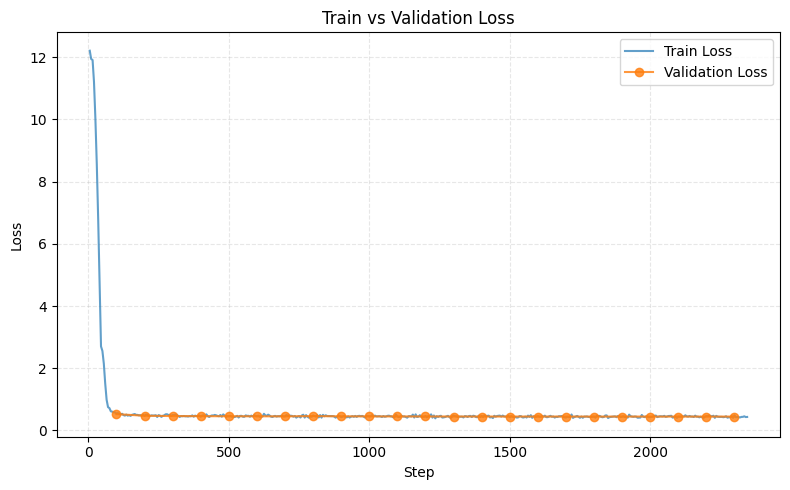

In [12]:
train_steps = [x['step'] for x in trainer.state.log_history if 'loss' in x and 'step' in x]
train_losses = [x['loss'] for x in trainer.state.log_history if 'loss' in x and 'step' in x]

eval_steps = [x['step'] for x in trainer.state.log_history if 'eval_loss' in x and 'step' in x]
eval_losses = [x['eval_loss'] for x in trainer.state.log_history if 'eval_loss' in x and 'step' in x]

train_steps, train_losses = zip(*sorted(zip(train_steps, train_losses)))
eval_steps, eval_losses = zip(*sorted(zip(eval_steps, eval_losses))) if eval_steps else ([], [])

plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_losses, label='Train Loss', alpha=0.7)
plt.plot(eval_steps, eval_losses, label='Validation Loss', marker='o', linestyle='-', alpha=0.8)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# **Token Accuracy**

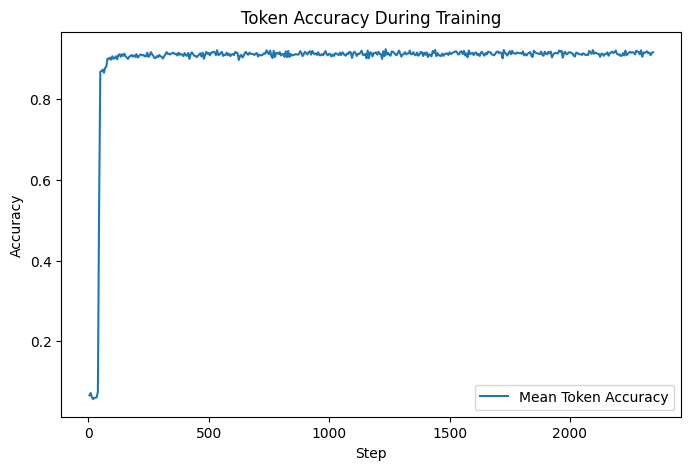

In [13]:
token_accs = [x['mean_token_accuracy'] for x in trainer.state.log_history if 'mean_token_accuracy' in x]

acc_steps = [x['step'] for x in trainer.state.log_history if 'mean_token_accuracy' in x]

plt.figure(figsize=(8,5))
plt.plot(acc_steps, token_accs, label='Mean Token Accuracy')
plt.xlabel('Step')
plt.ylabel('Accuracy')
plt.title('Token Accuracy During Training')
plt.legend()
plt.show()

# **Evaluate Model**

In [14]:
from tqdm import tqdm

bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

preds, refs = [], []
batch_size = 16

test_list = list(test_dataset)

for i in tqdm(range(0, len(test_list), batch_size), desc="Translation:"):
    batch = test_list[i : i + batch_size]
    
    prompts = [f"Translate English to Vietnamese:\nEnglish: {ex['en']}\nVietnamese:" for ex in batch]
    refs.extend([ex["vi"].strip() for ex in batch])
    
    inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            num_beams=1,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    
    batch_preds = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
    batch_preds = [p.split("Vietnamese:")[-1].strip() for p in batch_preds]
    
    preds.extend(batch_preds)

bleu_score = bleu.compute(predictions=preds, references=[[r] for r in refs])
rouge_score = rouge.compute(predictions=preds, references=refs)

print(f"\n🔹 BLEU: {bleu_score['bleu']:.4f}")
print("🔹 ROUGE Scores:")
for k, v in rouge_score.items():
    print(f"  {k}: {v:.4f}")

Translation:: 100%|██████████| 125/125 [14:41<00:00,  7.05s/it]



🔹 BLEU: 0.0362
🔹 ROUGE Scores:
  rouge1: 0.2982
  rouge2: 0.1566
  rougeL: 0.2542
  rougeLsum: 0.2544


# **Inference**

In [15]:
base_model_name = "Qwen/Qwen2.5-0.5B"
lora_checkpoint = "./qwen2.5-lora-en-vi/checkpoint-1500"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

# Load base model
model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

prompt = "Translate the following English sentence to Vietnamese. Output only the translation.\nEnglish: Hello\nVietnamese:"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False,
        num_beams=1,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
        repetition_penalty=1.2
    )

result = tokenizer.decode(outputs[0], skip_special_tokens=True)
translation = result.split("Vietnamese:")[-1].strip()
print("Translation:", translation)

Translation: Chào bạn


# **Đóng gói Model**

In [16]:
SOURCE_DIR = "./qwen2.5-lora-en-vi"
CHECKPOINT = "checkpoint-1500"
TARGET = os.path.join(SOURCE_DIR, CHECKPOINT)

OUTPUT_ZIP = "qwen2.5-lora.zip"

# Check if checkpoint exists
if not os.path.exists(TARGET):
    raise FileNotFoundError(f"Not found: {TARGET}")

temp_dir = "temp_checkpoint"
# Ensure temp directory is empty
os.makedirs(temp_dir, exist_ok=True)
shutil.rmtree(temp_dir)
os.makedirs(temp_dir)

print("Copying files from checkpoint...")
for file in os.listdir(TARGET):
    src = os.path.join(TARGET, file)
    dst = os.path.join(temp_dir, file)
    if os.path.isfile(src):
        shutil.copy(src, dst)
        print(f"-> {file}")

# Create ZIP archive
print(f"\nCompressing into {OUTPUT_ZIP}...")
with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(temp_dir):
        for f in files:
            file_path = os.path.join(root, f)
            arcname = os.path.relpath(file_path, temp_dir)
            z.write(file_path, arcname)

# Clean up temporary directory
shutil.rmtree(temp_dir)

# Output result
size_mb = os.path.getsize(OUTPUT_ZIP) / (1024**2)
print(f"File: {OUTPUT_ZIP} - Size: {size_mb:.1f} MB")

Copying files from checkpoint...
-> added_tokens.json
-> tokenizer.json
-> merges.txt
-> README.md
-> special_tokens_map.json
-> adapter_config.json
-> scaler.pt
-> training_args.bin
-> scheduler.pt
-> vocab.json
-> adapter_model.safetensors
-> optimizer.pt
-> chat_template.jinja
-> tokenizer_config.json
-> trainer_state.json
-> rng_state.pth

Compressing into qwen2.5-lora.zip...
File: qwen2.5-lora.zip - Size: 15.3 MB
